In [1]:
pip install pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

n = [2, 4, 6, 10, 20, 50]
p = [0.1, 0.25, 0.5, 0.75, 0.9, 0.99]

regras_k = {
    "k=1": lambda n: 1,
    "k=n/2": lambda n: n // 2,
    "k=n": lambda n: n,
}

def calcular_probabilidade_sistema_disponivel(n: int, k: int, p: float) -> float:
    soma = sum((math.factorial(n) / (math.factorial(i) * math.factorial(n - i))) * (p ** i) * (1 - p) ** (n - i) for i in range(0, k))
    return (1 - soma)

linhas = []
for ni in n:
    ks_vistos = set()
    for nome_k, regra_k in regras_k.items():
        ki = regra_k(ni)
        if ki in ks_vistos:
            continue
        ks_vistos.add(ki)
        for pi in p:
            resultado = calcular_probabilidade_sistema_disponivel(ni, ki, pi)
            linhas.append((ni, ki, pi, resultado))

tabela = pd.DataFrame(linhas, columns=["n", "k", "p", "Resultado"])
pd.set_option("display.float_format", "{:.10f}".format)

display(tabela)

,n,k,p,Resultado
0,2,1,0.1000000000,0.1900000000
1,2,1,0.2500000000,0.4375000000
2,2,1,0.5000000000,0.7500000000
3,2,1,0.7500000000,0.9375000000
4,2,1,0.9000000000,0.9900000000
...,...,...,...,...
97,50,50,0.2500000000,0.0000000000
98,50,50,0.5000000000,0.0000000000
99,50,50,0.7500000000,0.0000005663
100,50,50,0.9000000000,0.0051537752


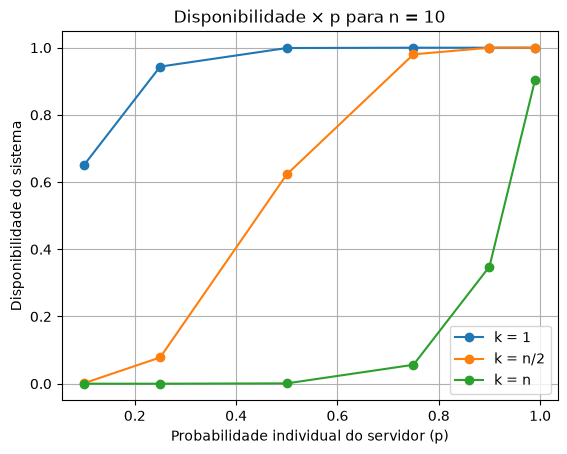

In [3]:
dados = tabela[tabela["n"] == 10]

dados_k1 = dados[dados["k"] == 1]
dados_k_metade = dados[dados["k"] == 5]
dados_kn = dados[dados["k"] == 10]

plt.plot(dados_k1["p"], dados_k1["Resultado"], marker="o", label="k = 1")

plt.plot(dados_k_metade["p"], dados_k_metade["Resultado"], marker="o", label="k = n/2")

plt.plot(dados_kn["p"], dados_kn["Resultado"], marker="o", label="k = n")

plt.xlabel("Probabilidade individual do servidor (p)")
plt.ylabel("Disponibilidade do sistema")
plt.title("Disponibilidade × p para n = 10")

plt.legend()
plt.grid()

plt.show()

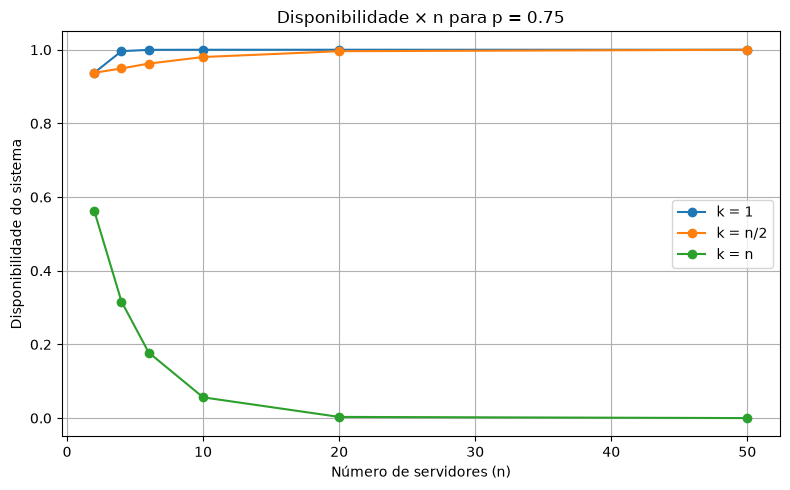

In [4]:
p_grafico = 0.75

dados = tabela[tabela["p"] == p_grafico]
dados_k1 = dados[dados["k"] == 1]
dados_k_metade = dados[dados["k"] == dados["n"] // 2]
dados_kn = dados[dados["k"] == dados["n"]]

plt.figure(figsize=(8, 5))

plt.plot(dados_k1["n"], dados_k1["Resultado"], marker="o", label="k = 1")

plt.plot(dados_k_metade["n"], dados_k_metade["Resultado"], marker="o", label="k = n/2")

plt.plot(dados_kn["n"], dados_kn["Resultado"], marker="o", label="k = n")

plt.xlabel("Número de servidores (n)")
plt.ylabel("Disponibilidade do sistema")
plt.title(f"Disponibilidade × n para p = {p_grafico}")

plt.ylim(-0.05, 1.05)

plt.legend()
plt.grid()
plt.tight_layout()

plt.show()

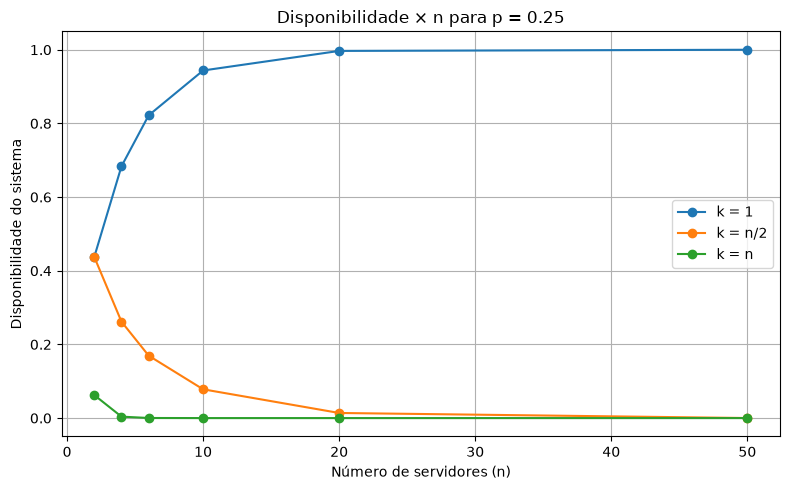

In [5]:
p_escolhido = 0.25

dados = tabela[tabela["p"] == p_escolhido]
dados_k1 = dados[dados["k"] == 1]
dados_k_metade = dados[dados["k"] == dados["n"] // 2]

dados_kn = dados[dados["k"] == dados["n"]]

plt.figure(figsize=(8, 5))

plt.plot(dados_k1["n"], dados_k1["Resultado"], marker="o", label="k = 1")

plt.plot(dados_k_metade["n"], dados_k_metade["Resultado"], marker="o", label="k = n/2")

plt.plot(dados_kn["n"], dados_kn["Resultado"], marker="o", label="k = n")


plt.xlabel("Número de servidores (n)")
plt.ylabel("Disponibilidade do sistema")
plt.title(f"Disponibilidade × n para p = {p_escolhido}")

plt.ylim(-0.05, 1.05)
plt.legend()
plt.grid()
plt.tight_layout()

plt.show()

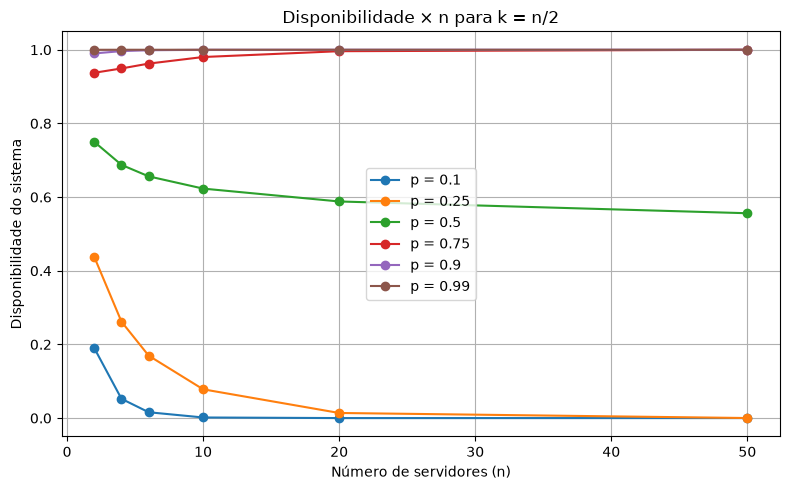

In [6]:
dados = tabela[tabela["k"] == tabela["n"] // 2]

plt.figure(figsize=(8, 5))

for pi in p:
    dados_p = dados[dados["p"] == pi]
    plt.plot(dados_p["n"], dados_p["Resultado"], marker="o", label=f"p = {pi}")

plt.xlabel("Número de servidores (n)")
plt.ylabel("Disponibilidade do sistema")
plt.title("Disponibilidade × n para k = n/2")

plt.ylim(-0.05, 1.05)
plt.legend()
plt.grid()
plt.tight_layout()

plt.show()

# Parte 2: Simulador estocástico

Para cada combinação de `n`, `k` e `p`, geramos um grande número de rodadas. Em cada rodada, sorteamos a disponibilidade de cada servidor individualmente (um número aleatório entre 0 e 1, comparado a `p`), contamos quantos servidores ficaram disponíveis e verificamos se o serviço permaneceu operacional (pelo menos `k` disponíveis). A frequência experimental é a proporção de rodadas bem-sucedidas, que comparamos com o valor obtido pela fórmula analítica.

In [7]:
rng = np.random.default_rng(42)

def simular_disponibilidade(n: int, k: int, p: float, num_rodadas: int = 100_000) -> float:
    disponiveis = rng.random((num_rodadas, n)) <= p
    servidores_disponiveis = disponiveis.sum(axis=1)
    sucessos = servidores_disponiveis >= k
    return sucessos.mean()

In [8]:
num_rodadas = 100_000

linhas_sim = []
for ni in n:
    ks_vistos = set()
    for nome_k, regra_k in regras_k.items():
        ki = regra_k(ni)
        if ki in ks_vistos:
            continue
        ks_vistos.add(ki)
        for pi in p:
            analitico = calcular_probabilidade_sistema_disponivel(ni, ki, pi)
            experimental = simular_disponibilidade(ni, ki, pi, num_rodadas)
            diferenca = abs(analitico - experimental)
            linhas_sim.append((ni, ki, pi, analitico, experimental, diferenca))

tabela_comparativa = pd.DataFrame(
    linhas_sim,
    columns=["n", "k", "p", "Analítico", "Experimental", "Diferença Absoluta"],
)

display(tabela_comparativa)

,n,k,p,Analítico,Experimental,Diferença Absoluta
0,2,1,0.1000000000,0.1900000000,0.1886000000,0.0014000000
1,2,1,0.2500000000,0.4375000000,0.4384200000,0.0009200000
2,2,1,0.5000000000,0.7500000000,0.7517500000,0.0017500000
3,2,1,0.7500000000,0.9375000000,0.9366500000,0.0008500000
4,2,1,0.9000000000,0.9900000000,0.9899000000,0.0001000000
...,...,...,...,...,...,...
97,50,50,0.2500000000,0.0000000000,0.0000000000,0.0000000000
98,50,50,0.5000000000,0.0000000000,0.0000000000,0.0000000000
99,50,50,0.7500000000,0.0000005663,0.0000000000,0.0000005663
100,50,50,0.9000000000,0.0051537752,0.0052500000,0.0000962248


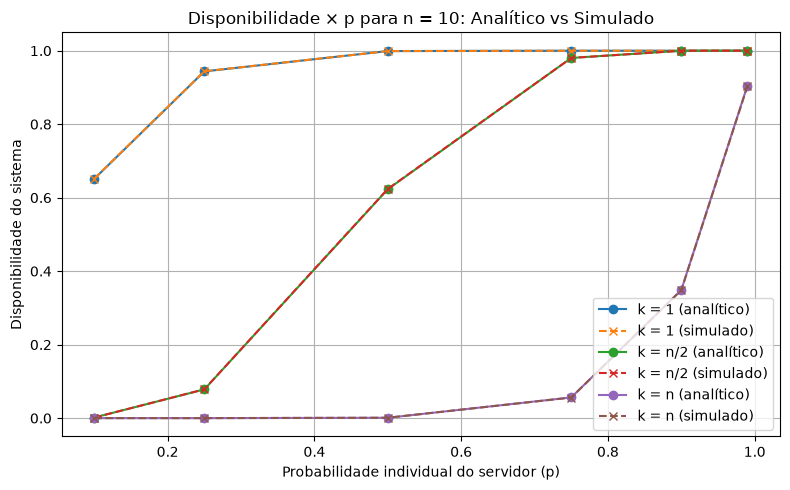

In [9]:
dados_comp = tabela_comparativa[tabela_comparativa["n"] == 10]

plt.figure(figsize=(8, 5))

for ki, label in [(1, "k = 1"), (5, "k = n/2"), (10, "k = n")]:
    d = dados_comp[dados_comp["k"] == ki]
    plt.plot(d["p"], d["Analítico"], marker="o", label=f"{label} (analítico)")
    plt.plot(d["p"], d["Experimental"], marker="x", linestyle="--", label=f"{label} (simulado)")

plt.xlabel("Probabilidade individual do servidor (p)")
plt.ylabel("Disponibilidade do sistema")
plt.title("Disponibilidade × p para n = 10: Analítico vs Simulado")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

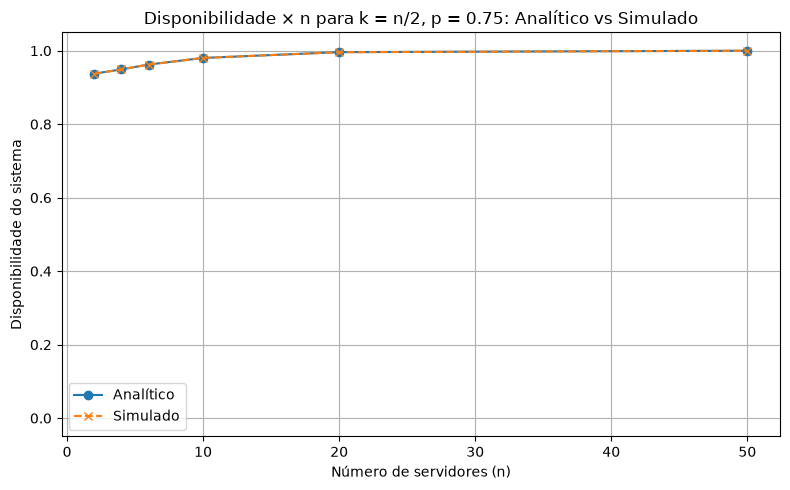

In [10]:
p_grafico = 0.75

dados_comp2 = tabela_comparativa[
    (tabela_comparativa["p"] == p_grafico)
    & (tabela_comparativa["k"] == tabela_comparativa["n"] // 2)
]

plt.figure(figsize=(8, 5))
plt.plot(dados_comp2["n"], dados_comp2["Analítico"], marker="o", label="Analítico")
plt.plot(dados_comp2["n"], dados_comp2["Experimental"], marker="x", linestyle="--", label="Simulado")

plt.xlabel("Número de servidores (n)")
plt.ylabel("Disponibilidade do sistema")
plt.title(f"Disponibilidade × n para k = n/2, p = {p_grafico}: Analítico vs Simulado")
plt.ylim(-0.05, 1.05)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [11]:
print("Maior diferença absoluta observada:", tabela_comparativa["Diferença Absoluta"].max())
print("Diferença média:", tabela_comparativa["Diferença Absoluta"].mean())

Maior diferença absoluta observada: 0.003210000000000046
Diferença média: 0.00041898143380806517
